In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import json

In [3]:
df = pd.read_csv("../../data/raw/raipur_satellite.csv")

df.head()

,system:index,LST,NDBI,NDVI,NDWI,QA_PIXEL,QA_RADSAT,SR_B1,SR_B2,SR_B3,...,ST_ATRAN,ST_B10,ST_CDIST,ST_DRAD,ST_EMIS,ST_EMSD,ST_QA,ST_TRAD,ST_URAD,.geo
0,0,49.324769,0.044834,0.107286,-0.129500,21824.0,0.0,9129.0,9589.5,10869.5,...,6182.0,50753.0,522.0,1518.5,9689.5,92.0,255.0,10817.5,3193.5,"{""type"":""Point"",""coordinates"":[81.559776041052..."
1,1,56.794852,0.045984,0.108955,-0.150005,21824.0,0.0,8906.5,9691.0,11297.5,...,6360.5,52938.5,13969.0,1466.0,9675.0,103.0,237.0,11968.0,3062.5,"{""type"":""Point"",""coordinates"":[81.696184536179..."
2,2,50.919275,0.102545,0.114751,-0.158930,21824.0,0.0,9655.0,10283.5,11953.5,...,6199.5,51219.5,5430.0,1508.5,9641.0,267.0,347.0,11242.5,3171.5,"{""type"":""Point"",""coordinates"":[81.753923539858..."
3,3,46.132338,-0.008944,0.098333,-0.085027,21824.0,0.0,8347.0,8804.0,10083.0,...,6036.0,49819.0,399.0,1556.0,9560.0,313.0,339.0,10597.0,3291.0,"{""type"":""Point"",""coordinates"":[81.674762104758..."
4,4,49.425601,0.028813,0.167497,-0.185644,21824.0,0.0,9012.0,9606.0,11107.0,...,5891.0,50782.5,5632.0,1598.5,9665.5,120.0,306.0,10956.5,3398.0,"{""type"":""Point"",""coordinates"":[81.622394837102..."


In [4]:
df.shape

(2500, 25)

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [7]:
df[['LST','NDVI','NDBI','NDWI']].describe()

,LST,NDVI,NDBI,NDWI
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,47.914786,0.140022,0.014221,-0.159113
std,4.401990,0.047311,0.045664,0.042182
min,35.820172,-0.036489,-0.238544,-0.376857
25%,45.156066,0.109666,-0.009191,-0.181952
50%,47.631995,0.134866,0.019638,-0.160118
75%,50.156202,0.163604,0.044782,-0.137063
max,61.368163,0.413858,0.159983,0.041048


In [8]:
def extract_coordinates(geo_string):
    geo = json.loads(geo_string)
    
    longitude = geo["coordinates"][0]
    latitude = geo["coordinates"][1]
    
    return pd.Series([longitude, latitude])


df[['longitude','latitude']] = df['.geo'].apply(extract_coordinates)

df.head()

,system:index,LST,NDBI,NDVI,NDWI,QA_PIXEL,QA_RADSAT,SR_B1,SR_B2,SR_B3,...,ST_CDIST,ST_DRAD,ST_EMIS,ST_EMSD,ST_QA,ST_TRAD,ST_URAD,.geo,longitude,latitude
0,0,49.324769,0.044834,0.107286,-0.129500,21824.0,0.0,9129.0,9589.5,10869.5,...,522.0,1518.5,9689.5,92.0,255.0,10817.5,3193.5,"{""type"":""Point"",""coordinates"":[81.559776041052...",81.559776,21.269197
1,1,56.794852,0.045984,0.108955,-0.150005,21824.0,0.0,8906.5,9691.0,11297.5,...,13969.0,1466.0,9675.0,103.0,237.0,11968.0,3062.5,"{""type"":""Point"",""coordinates"":[81.696184536179...",81.696185,21.134942
2,2,50.919275,0.102545,0.114751,-0.158930,21824.0,0.0,9655.0,10283.5,11953.5,...,5430.0,1508.5,9641.0,267.0,347.0,11242.5,3171.5,"{""type"":""Point"",""coordinates"":[81.753923539858...",81.753924,21.210473
3,3,46.132338,-0.008944,0.098333,-0.085027,21824.0,0.0,8347.0,8804.0,10083.0,...,399.0,1556.0,9560.0,313.0,339.0,10597.0,3291.0,"{""type"":""Point"",""coordinates"":[81.674762104758...",81.674762,21.357004
4,4,49.425601,0.028813,0.167497,-0.185644,21824.0,0.0,9012.0,9606.0,11107.0,...,5632.0,1598.5,9665.5,120.0,306.0,10956.5,3398.0,"{""type"":""Point"",""coordinates"":[81.622394837102...",81.622395,21.179558


In [9]:
df.to_csv(
    "../../data/processed/raipur_features.csv",
    index=False
)

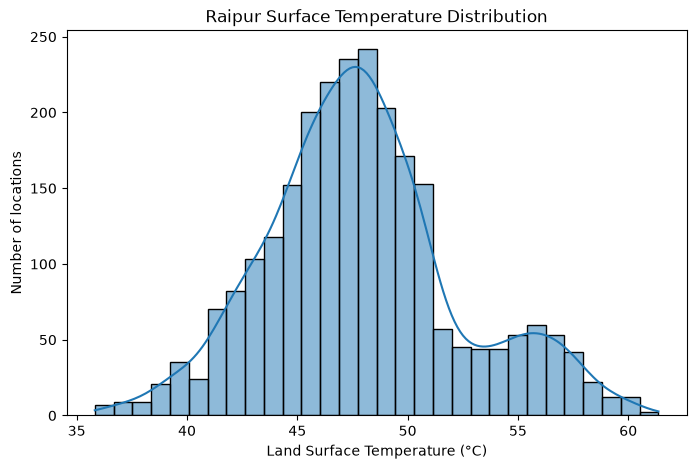

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['LST'],
    bins=30,
    kde=True
)

plt.xlabel("Land Surface Temperature (°C)")
plt.ylabel("Number of locations")
plt.title("Raipur Surface Temperature Distribution")

plt.show()

In [13]:
import folium


raipur_map = folium.Map(
    location=[21.25,81.63],
    zoom_start=11
)


for _, row in df.iterrows():

    folium.CircleMarker(
        location=[
            row['latitude'],
            row['longitude']
        ],
        radius=3,
        color=None,
        fill=True,
        fill_color='red',
        fill_opacity=0.5
    ).add_to(raipur_map)


from IPython.display import display
display(raipur_map)